# 📊 Notebook 01: Exploratory Data Analysis & Data Preparation

This notebook explores the arXiv metadata dataset and prepares it for embedding.

**What we'll do:**
1. Load the arXiv JSON dataset (filtered to CS papers)
2. Explore paper counts, category distributions, abstract lengths
3. Visualize temporal trends
4. Save processed data for downstream use

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_arxiv_data, save_processed_data, get_dataset_stats
from src.utils import setup_logging

setup_logging('INFO')
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)

print('Setup complete!')

Setup complete!


## 1. Load the Dataset

We load the arXiv metadata JSON file, filtering to Computer Science papers.
Adjust `max_records` to control how many papers to load (None = all CS papers, ~500k+).

In [2]:
# Path to the arXiv dataset
# Update this path if your file is in a different location
DATA_PATH = '../../arxiv-metadata-oai-snapshot.json'

# Load papers (adjust max_records for faster testing)
# Set max_records=None to load all CS papers
MAX_RECORDS = 50000  # Start with 50k for manageable size

df = load_arxiv_data(DATA_PATH, max_records=MAX_RECORDS, cs_only=True)
print(f'\nLoaded {len(df)} papers')
print(f'Columns: {df.columns.tolist()}')
df.head()

14:48:21 | src.data_loader | INFO | Loading arXiv data from ../../arxiv-metadata-oai-snapshot.json...
Loading papers: 458709 papers [00:03, 117741.83 papers/s]
14:48:25 | src.data_loader | INFO | Loaded 50000 papers.



Loaded 50000 papers
Columns: ['id', 'title', 'abstract', 'authors', 'categories', 'update_date', 'text', 'primary_category', 'year']


,id,title,abstract,authors,categories,update_date,text,primary_category,year
0,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-pe...",Ileana Streinu and Louis Theran,math.CO cs.CG,2008-12-13,Sparsity-certifying Graph Decompositions We de...,math.CO,2008
1,0704.0046,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldmann...","I. Csiszar, F. Hiai and D. Petz",quant-ph cs.IT math.IT,2009-11-13,A limit relation for entropy and channel capac...,quant-ph,2009
2,0704.0047,Intelligent location of simultaneously active ...,The intelligent acoustic emission locator is d...,T. Kosel and I. Grabec,cs.NE cs.AI,2009-09-29,Intelligent location of simultaneously active ...,cs.NE,2009
3,0704.0050,Intelligent location of simultaneously active ...,Part I describes an intelligent acoustic emiss...,T. Kosel and I. Grabec,cs.NE cs.AI,2007-05-23,Intelligent location of simultaneously active ...,cs.NE,2007
4,0704.0062,On-line Viterbi Algorithm and Its Relationship...,"In this paper, we introduce the on-line Viterb...","Rastislav \v{S}r\'amek, Bro\v{n}a Brejov\'a, T...",cs.DS,2010-01-25,On-line Viterbi Algorithm and Its Relationship...,cs.DS,2010


## 2. Basic Statistics

In [3]:
stats = get_dataset_stats(df)
print('=== Dataset Statistics ===')
for key, value in stats.items():
    if key != 'top_categories':
        print(f'  {key}: {value}')

print(f'\n=== Top 10 Categories ===')
for cat, count in stats['top_categories'].items():
    print(f'  {cat}: {count:,} papers')

=== Dataset Statistics ===
  total_papers: 50000
  unique_categories: 136
  year_range: (2007, 2026)
  avg_abstract_length: 943.38374
  avg_title_length: 66.87486

=== Top 10 Categories ===
  cs.IT: 7,838 papers
  cs.AI: 3,244 papers
  cs.NI: 2,863 papers
  cs.DS: 2,594 papers
  cs.LO: 2,066 papers
  cs.CR: 1,969 papers
  cs.LG: 1,933 papers
  cs.CV: 1,538 papers
  cs.DC: 1,386 papers
  cs.DM: 1,256 papers


In [4]:
# Missing values check
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Data Types ===')
print(df.dtypes)

=== Missing Values ===
id                  0
title               0
abstract            0
authors             0
categories          0
update_date         0
text                0
primary_category    0
year                0
dtype: int64

=== Data Types ===
id                  object
title               object
abstract            object
authors             object
categories          object
update_date         object
text                object
primary_category    object
year                 int32
dtype: object


## 3. Category Distribution

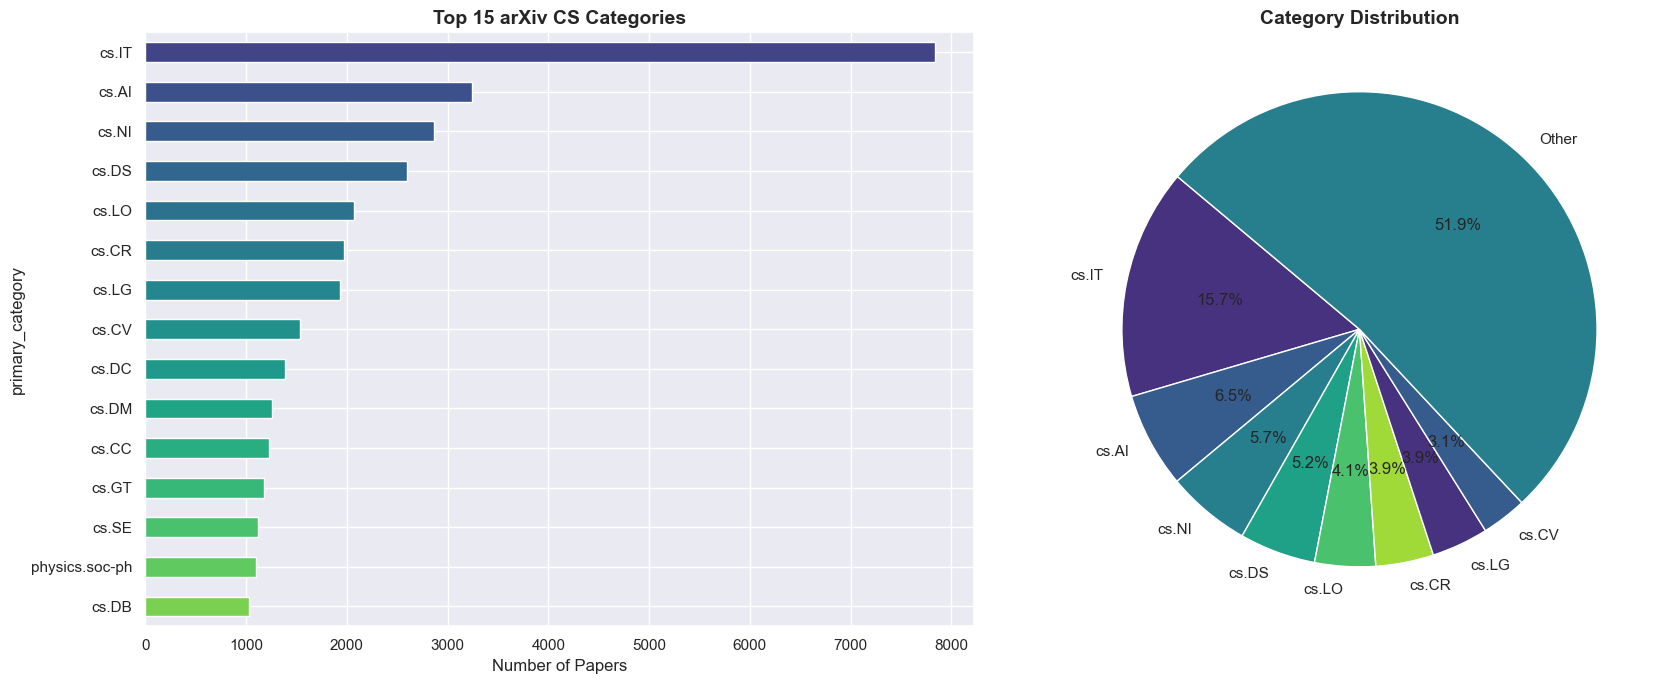

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Top 15 categories bar chart
top_cats = df['primary_category'].value_counts().head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_cats)))
top_cats.plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Top 15 arXiv CS Categories', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Papers')
ax1.invert_yaxis()

# Pie chart of top categories
top5 = df['primary_category'].value_counts().head(8)
other = pd.Series({'Other': len(df) - top5.sum()})
pie_data = pd.concat([top5, other])
pie_data.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=140)
ax2.set_title('Category Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('../data/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Abstract Length Analysis

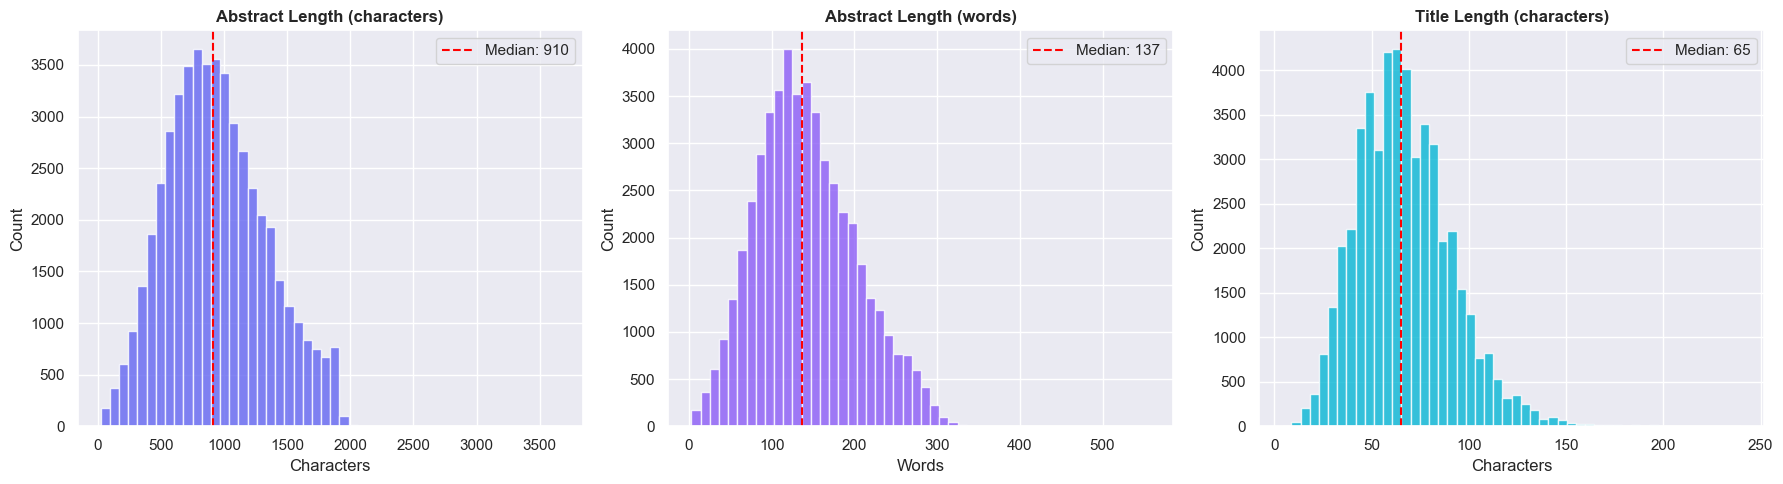

Abstract stats: mean=142 words, median=137, max=558


In [6]:
df['abstract_length'] = df['abstract'].str.len()
df['abstract_words'] = df['abstract'].str.split().str.len()
df['title_length'] = df['title'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Abstract character length
axes[0].hist(df['abstract_length'].dropna(), bins=50, color='#6366f1', alpha=0.8, edgecolor='white')
axes[0].set_title('Abstract Length (characters)', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')
axes[0].axvline(df['abstract_length'].median(), color='red', linestyle='--', label=f'Median: {df["abstract_length"].median():.0f}')
axes[0].legend()

# Abstract word count
axes[1].hist(df['abstract_words'].dropna(), bins=50, color='#8b5cf6', alpha=0.8, edgecolor='white')
axes[1].set_title('Abstract Length (words)', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')
axes[1].axvline(df['abstract_words'].median(), color='red', linestyle='--', label=f'Median: {df["abstract_words"].median():.0f}')
axes[1].legend()

# Title length
axes[2].hist(df['title_length'].dropna(), bins=50, color='#06b6d4', alpha=0.8, edgecolor='white')
axes[2].set_title('Title Length (characters)', fontweight='bold')
axes[2].set_xlabel('Characters')
axes[2].set_ylabel('Count')
axes[2].axvline(df['title_length'].median(), color='red', linestyle='--', label=f'Median: {df["title_length"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Abstract stats: mean={df["abstract_words"].mean():.0f} words, '
      f'median={df["abstract_words"].median():.0f}, '
      f'max={df["abstract_words"].max():.0f}')

## 5. Temporal Trends

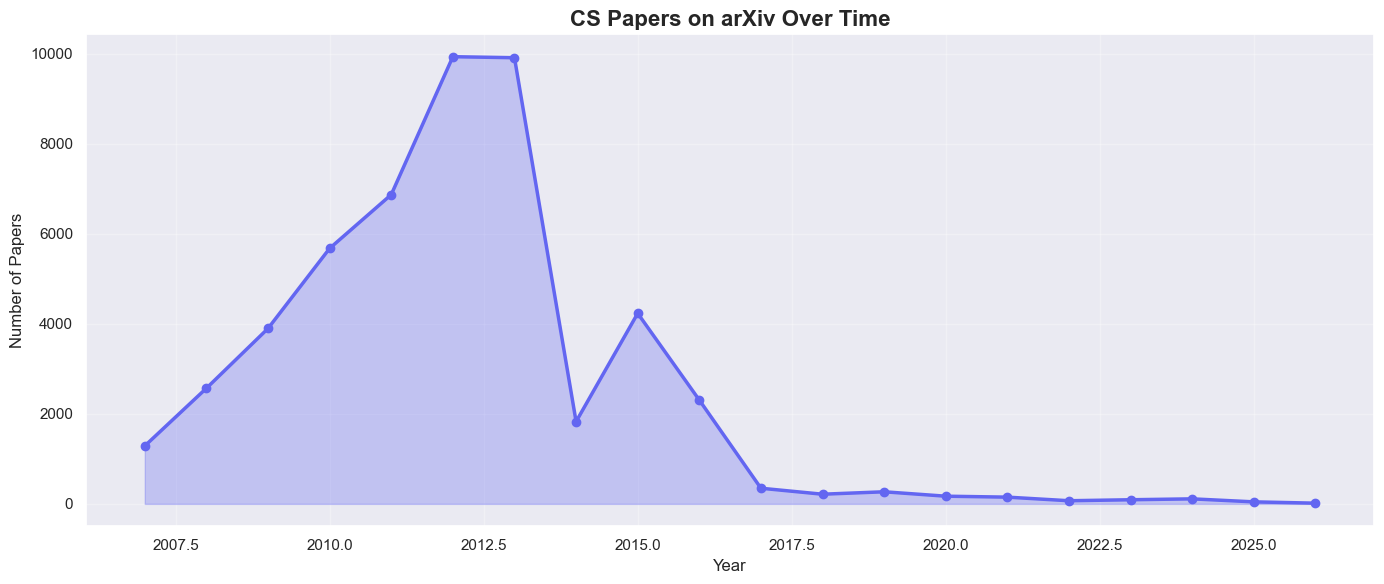

In [7]:
yearly = df.groupby('year').size().reset_index(name='count')
yearly = yearly[yearly['year'] >= 2000]  # Focus on 2000+

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(yearly['year'], yearly['count'], alpha=0.3, color='#6366f1')
ax.plot(yearly['year'], yearly['count'], color='#6366f1', linewidth=2.5, marker='o', markersize=6)
ax.set_title('CS Papers on arXiv Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Papers', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

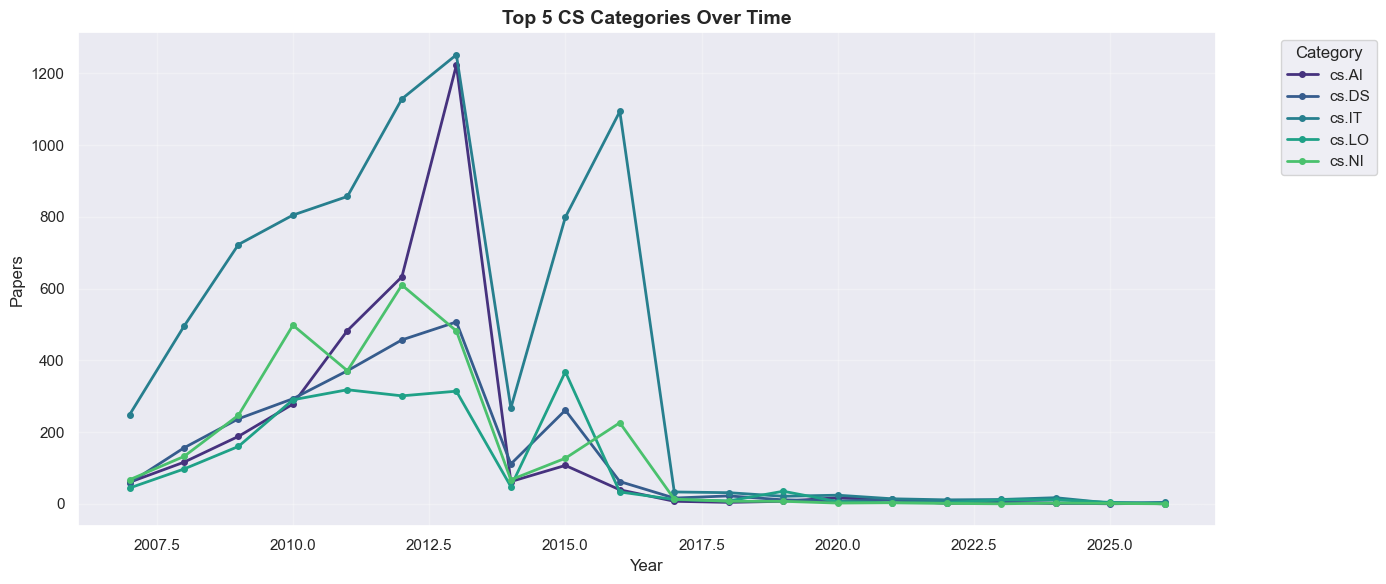

In [8]:
# Category trends over time (top 5 categories)
top5_cats = df['primary_category'].value_counts().head(5).index.tolist()
cat_yearly = df[df['primary_category'].isin(top5_cats)].groupby(['year', 'primary_category']).size().unstack(fill_value=0)
cat_yearly = cat_yearly[cat_yearly.index >= 2005]

fig, ax = plt.subplots(figsize=(14, 6))
cat_yearly.plot(ax=ax, linewidth=2, marker='o', markersize=4)
ax.set_title('Top 5 CS Categories Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Papers')
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/category_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sample Papers

In [9]:
print('=== Sample Papers ===')
for _, row in df.sample(3, random_state=42).iterrows():
    print(f'\n📄 {row["title"]}')
    print(f'   Authors: {row["authors"][:80]}...')
    print(f'   Category: {row["primary_category"]} | Year: {row["year"]}')
    print(f'   Abstract: {row["abstract"][:200]}...')
    print(f'   Text field length: {len(row["text"])} chars')

=== Sample Papers ===

📄 Green Traffic Engineering for Future Core Networks
   Authors: George Athanasiou...
   Category: cs.NI | Year: 2012
   Abstract: An important goal towards the design of Future Networks is to achieve the best ratio of performance to energy consumption and at the same time assure manageability. This paper presents a general probl...
   Text field length: 618 chars

📄 Can Iterative Decoding for Erasure Correlated Sources be Universal?
   Authors: Arvind Yedla, Henry D. Pfister, Krishna R. Narayanan...
   Category: cs.IT | Year: 2009
   Abstract: In this paper, we consider a few iterative decoding schemes for the joint source-channel coding of correlated sources. Specifically, we consider the joint source-channel coding of two erasure correlat...
   Text field length: 1106 chars

📄 An Energy Efficiency Perspective on Training for Fading Channels
   Authors: Mustafa Cenk Gursoy...
   Category: cs.IT | Year: 2016
   Abstract: In this paper, the bit energy requirement

## 7. Save Processed Data

In [10]:
# Save to parquet for fast loading in subsequent notebooks
import os
os.makedirs('../data', exist_ok=True)
save_processed_data(df, '../data/papers_processed.parquet')
print(f'\n✅ Saved {len(df)} processed papers to data/papers_processed.parquet')
print(f'   File size: {os.path.getsize("../data/papers_processed.parquet") / 1e6:.1f} MB')

14:48:29 | src.data_loader | INFO | Saved processed data to ../data/papers_processed.parquet (50000 records)



✅ Saved 50000 processed papers to data/papers_processed.parquet
   File size: 58.9 MB


## ✅ Summary

**Key findings:**
- Dataset contains CS papers from arXiv with titles, abstracts, and metadata
- Category distribution shows the most popular CS subcategories
- Paper submissions trending upward over time
- Abstract lengths are appropriate for embedding models (~100-300 words typically)

**Next:** Run `02_embeddings_and_index.ipynb` to generate embeddings and build the FAISS index.